In [13]:
import pandas as pd
import numpy as np
from pwnlib.constants.linux.alpha import INT64_MAX

In [14]:
PATH = './data'
TARGET = 'SalePrice'

In [15]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

In [16]:
df = pd.read_csv(PATH + '/train.csv')

### Create train and test set ###

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, shuffle=True, random_state=42
)

train_ids = X_train.pop('Id')
test_ids = X_test.pop('Id')

### Data Cleaning ###

In [62]:
cat_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
num_cols = [col for col in X_train.columns if X_train[col].dtype != 'object']

In [19]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', 'drop',                                                 cat_cols),
        ('num', SimpleImputer(missing_values=np.nan, strategy='mean'),  num_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

### Full Pipeline ###

In [59]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler

preprocessing_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('rfe', RFE(estimator=LinearRegression(), n_features_to_select=20))
])

preprocessing_pipeline.set_output(transform='pandas')

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

### Preprocess Train and Test Data ###

In [64]:
preprocessing_pipeline.fit(X_train, y_train)
X_train_t = preprocessing_pipeline.transform(X_train)
X_test_t = preprocessing_pipeline.transform(X_test)

### Simple Linear Regression ###

In [137]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import KFold, cross_validate

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()

cv_results = cross_validate(
    model, X_train_t, np.log1p(y_train),
    cv=kf,
    scoring=['neg_root_mean_squared_error'],
    return_train_score=True,
)

cv_results_df = pd.DataFrame(cv_results)

train_root_mean_squared_error = -cv_results_df.mean()['train_neg_root_mean_squared_error']
validation_root_mean_squared_error = -cv_results_df.mean()['test_neg_root_mean_squared_error']

print(f'train_rmse: {train_root_mean_squared_error}\nvalidation_rmse: {validation_root_mean_squared_error}')

train_rmse: 0.14506855655206358
validation_rmse: 0.15480471083419378


### Decision Trees ###

In [186]:
from sklearn.tree import DecisionTreeRegressor

kf = KFold(n_splits=5, shuffle=True, random_state=42)

params_grid = [
    {},
    # {'max_depth': 30, 'min_samples_split': 50, 'min_samples_leaf': 15, 'criterion': 'squared_error'},
]

min_val_loss = 1<<20

for param in params_grid:
    model = DecisionTreeRegressor(**param, random_state=42)

    cv_results = cross_validate(
        model, X_train_t, np.log1p(y_train),
        cv=kf,
        scoring=['neg_root_mean_squared_error'],
        return_train_score=True,
    )

    cv_results_df = pd.DataFrame(cv_results)

    train_root_mean_squared_error = -cv_results_df.mean()['train_neg_root_mean_squared_error']
    validation_root_mean_squared_error = -cv_results_df.mean()['test_neg_root_mean_squared_error']

    print(f'model_params: {param}')
    print(f'train_rmse: {train_root_mean_squared_error}')
    print(f'validation_rmse: {validation_root_mean_squared_error}')
    print(f'-----------------------------------')

    min_val_loss = min(min_val_loss, validation_root_mean_squared_error)

print(min_val_loss)

model_params: {}
train_rmse: 0.0010221853754178284
validation_rmse: 0.21091746615985457
-----------------------------------
0.21091746615985457


In [136]:
from sklearn.metrics import root_mean_squared_error

model.fit(X_train_t, y_train)
y_pred = model.predict(X_test_t)
print(root_mean_squared_error(np.log1p(y_pred), np.log1p(y_test)))

0.19342342717706906


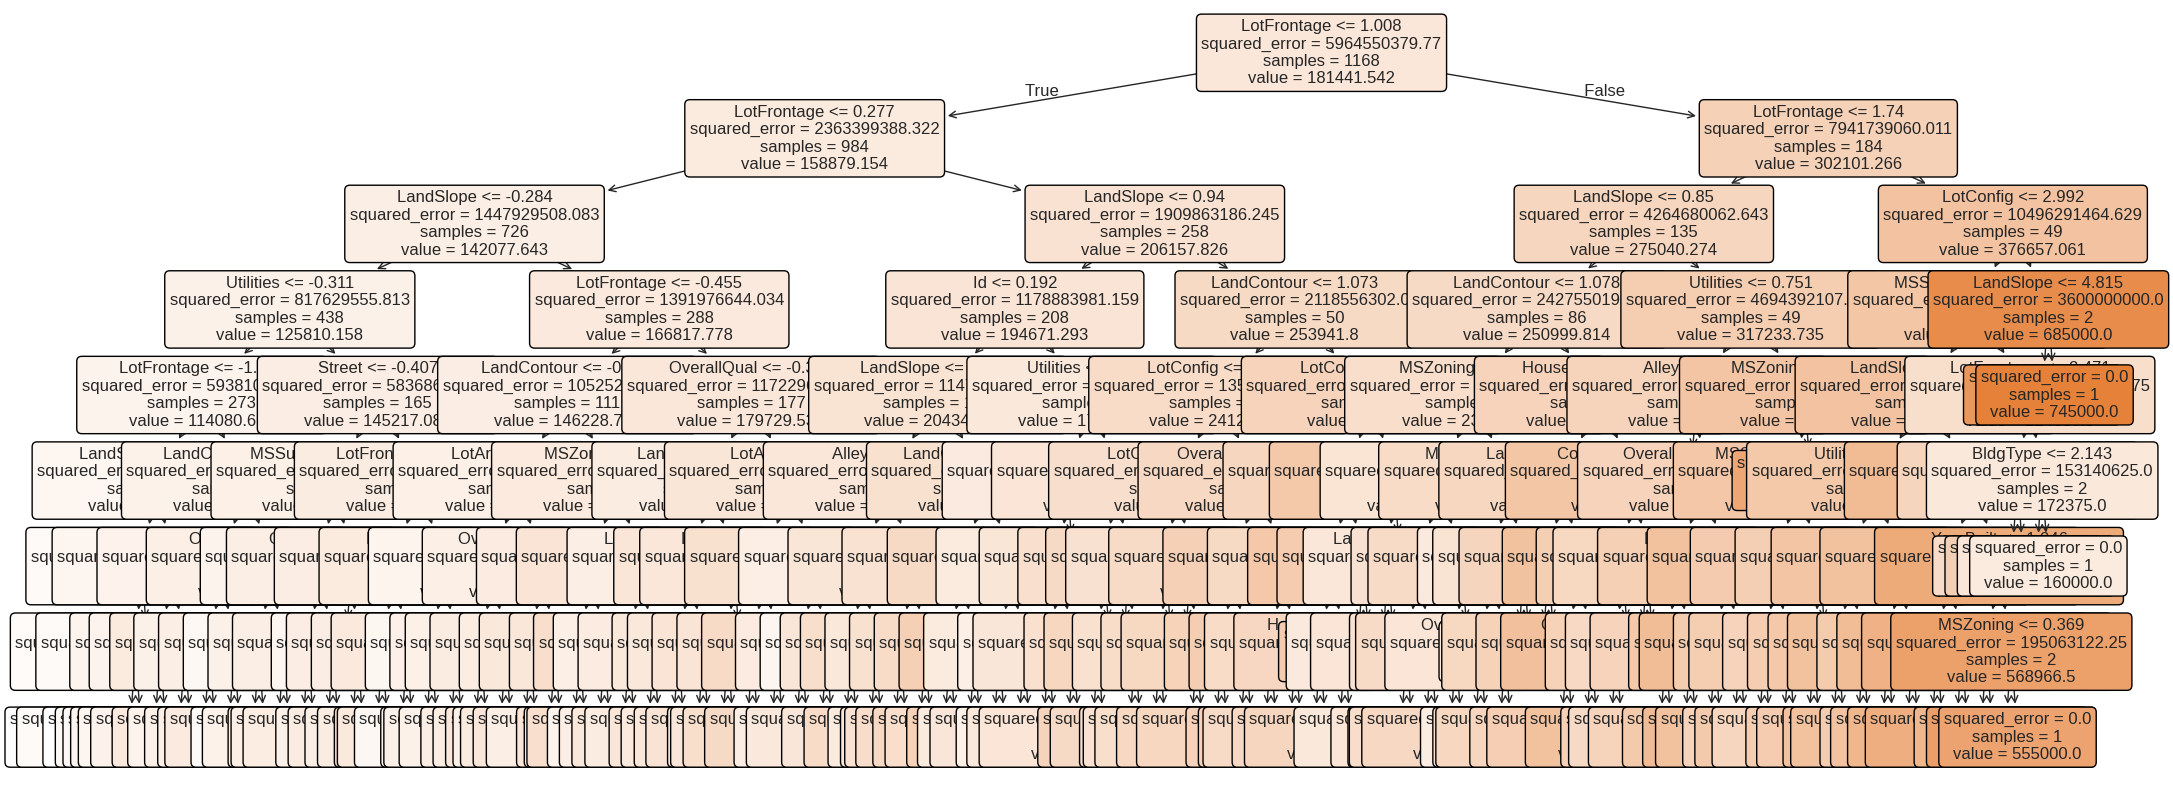

In [134]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.style.use('seaborn-v0_8-whitegrid')
model.fit(X_train_t, y_train)

plt.figure(figsize=(25, 10))
plot_tree(model,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=12)
plt.show()